# 06. Trực quan hoá: insight dataset + SHAP + CIES

Ba phần:
1. **Insight về dataset** (Sparkov, ULB) — chỉ những góc nhìn có tín hiệu thật, kèm 1 giả thuyết phổ biến nhưng **sai** trên dữ liệu này.
2. **SHAP** — model nào "nhìn" feature nào, các model có đồng thuận không.
3. **CIES** — độ ổn định của giải thích qua bootstrap: theo model × kỹ thuật, theo từng feature, và giữa 2 dataset.

Mọi hàm vẽ nằm trong `src/visualization/` (`dataset.py`, `explain.py`); ảnh lưu vào `reports/figures/`.
Phần 3 cần file kết quả của notebook 04/05 (`results/cies_summary_results*.json`) — chưa có thì tự bỏ qua.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, RESULTS_DIR, FIGURES_DIR, TRAIN_FILE, TEST_FILE, TARGET_COL, ULB_TARGET_COL, SEED
from src.visualization import dataset as D
from src.visualization import explain as E

FIG = FIGURES_DIR
FIG.mkdir(parents=True, exist_ok=True)
%matplotlib inline

## 1. Bối cảnh: hai dataset

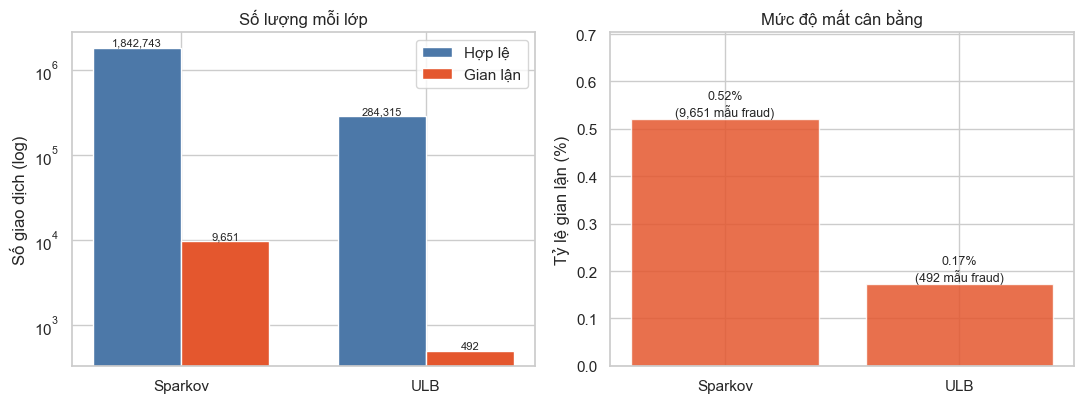

In [2]:
sparkov = pd.concat([pd.read_csv(RAW_DATA_DIR / TRAIN_FILE), pd.read_csv(RAW_DATA_DIR / TEST_FILE)], ignore_index=True)
ulb = pd.concat([pd.read_parquet(PROCESSED_DATA_DIR / 'ulb_train.parquet'),
                 pd.read_parquet(PROCESSED_DATA_DIR / 'ulb_test.parquet')], ignore_index=True)
D.plot_imbalance_comparison(sparkov[TARGET_COL], ulb[ULB_TARGET_COL], FIG / 'insight_imbalance.png');

ULB mất cân bằng nặng hơn Sparkov ~3 lần (0.17% so với 0.52%) và chỉ có **492** mẫu fraud tuyệt đối —
đó là lý do các kỹ thuật resampling (SMOTE...) có thể cho kết quả rất khác giữa 2 dataset.

## 2. Sparkov — dữ liệu nói gì

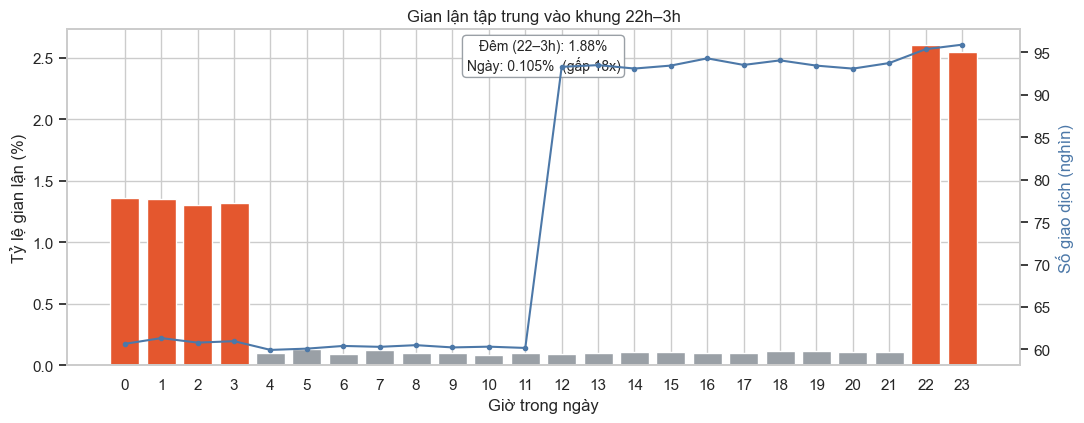

In [3]:
sp = D.add_sparkov_derived(sparkov)
D.plot_hour_profile(sp, FIG / 'insight_hour.png');

In [4]:
# Kiểm tra "hiệu ứng đợt lộ thẻ" (spree): nhiều insight bên dưới ban đầu tính trên TỪNG DÒNG
# giao dịch, nhưng 1 thẻ bị lộ thường sinh ra NHIỀU dòng fraud liên tiếp (kẻ gian rút/quẹt
# liên tục) — các dòng đó không độc lập, đếm theo dòng dễ phóng đại tín hiệu. Tách riêng
# "fraud đầu đợt" (dòng liền trước, cùng thẻ, KHÔNG phải fraud) để đối chiếu.
sp_sorted = sp.sort_values(['cc_num', 'ts']).reset_index(drop=True)
sp_sorted['prev_is_fraud'] = sp_sorted.groupby('cc_num')['is_fraud'].shift()
sp_sorted['is_spree_start'] = (sp_sorted['is_fraud'] == 1) & (sp_sorted['prev_is_fraud'] != 1)

fraud_rows = sp_sorted[sp_sorted['is_fraud'] == 1]
spree_start = sp_sorted[sp_sorted['is_spree_start']]
pct_continuation = 100 * (fraud_rows['prev_is_fraud'] == 1).mean()

print(f"Dòng fraud: {len(fraud_rows):,} | Số thẻ có fraud: {fraud_rows['cc_num'].nunique():,} "
      f"| Số đợt lộ thẻ (spree, đếm = fraud đầu tiên/thẻ): {len(spree_start):,}")
print(f"{pct_continuation:.1f}% dòng fraud là TIẾP NỐI 1 đợt lộ thẻ đã có sẵn (không phải sự kiện độc lập mới)")

Dòng fraud: 9,651 | Số thẻ có fraud: 976 | Số đợt lộ thẻ (spree, đếm = fraud đầu tiên/thẻ): 977
89.9% dòng fraud là TIẾP NỐI 1 đợt lộ thẻ đã có sẵn (không phải sự kiện độc lập mới)


**Cảnh báo phương pháp — hiệu ứng đợt lộ thẻ (spree).** Một thẻ bị lộ thường sinh ra
nhiều dòng fraud liên tiếp trong thời gian ngắn (kẻ gian rút/quẹt dồn dập). Cell trên cho
thấy chỉ ~977 đợt lộ thẻ độc lập nhưng tạo ra 9.651 dòng fraud — nghĩa là các thống kê tính
theo *dòng* (như bên dưới) có thể chỉ phản ánh đặc điểm của vài trăm đợt, bị đếm lặp nhiều
lần, chứ không phải một tín hiệu phổ quát trên mọi giao dịch fraud. Với mỗi insight, đã đối
chiếu thêm bằng cách chỉ tính **dòng fraud đầu tiên của mỗi đợt** (`is_spree_start`, độc lập
hơn) — kết quả nào đổi nhiều khi đối chiếu sẽ được ghi rõ.

**Giờ đêm (22h–3h) có tỷ lệ fraud gấp ~18 lần ban ngày** dù lưu lượng đêm *thấp hơn*. Tín hiệu
này **vẫn đúng** khi chỉ tính riêng dòng đầu đợt (`is_spree_start`): 86,6% đợt bắt đầu vào khung
giờ đêm, so với 84,6% nếu tính mọi dòng fraud và chỉ 23,2% ở giao dịch hợp lệ — không phải hiệu
ứng đếm lặp. Lưu ý đường lưu lượng nhảy vọt từ 12h — Sparkov là dữ liệu **mô phỏng**, nên những
hình dạng quá "sạch" như vậy là dấu vết của bộ sinh dữ liệu; đây cũng là lý do cần kiểm chứng trên
ULB (dữ liệu thật).

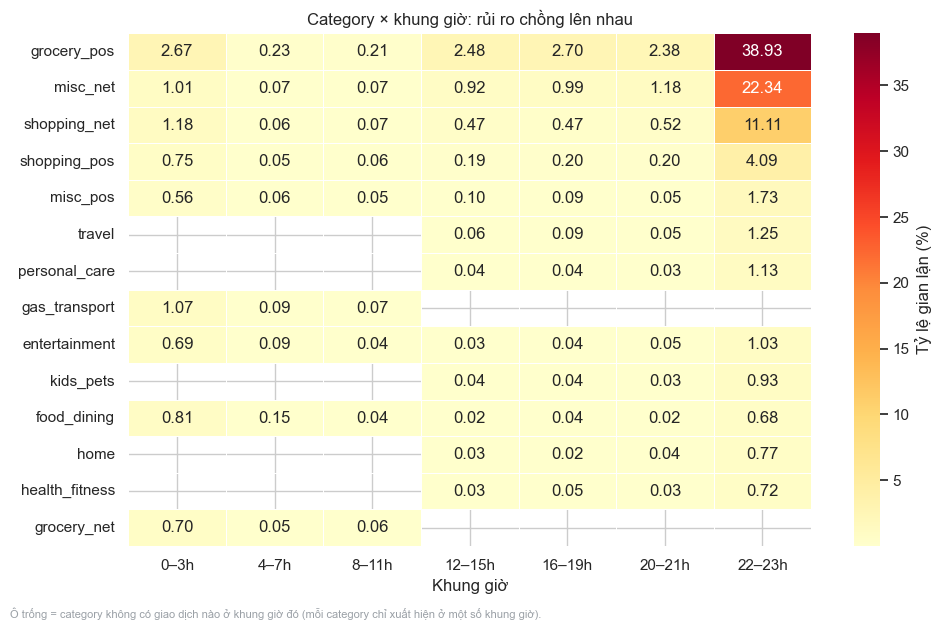

In [5]:
D.plot_hour_category_heatmap(sp, FIG / 'insight_hour_category.png');

**Cần rút lại phần lớn nhận xét này.** Tính theo dòng, `grocery_pos` lúc 22–23h có ~39% là
fraud — nhưng khi chỉ tính dòng đầu đợt lộ thẻ (loại bỏ đếm lặp trong 1 đợt), tỷ lệ này tụt còn
**~1,8%**, gần với `grocery_pos` giờ khác. Tức là con số 39% chủ yếu đến từ việc 1 vài đợt lộ thẻ
tình cờ quẹt nhiều lần ở `grocery_pos` vào ban đêm, không phải category này thật sự rủi ro hơn ở
khung giờ đó. **Không nên dùng heatmap này để kết luận về category × giờ** cho tới khi vẽ lại bằng
dữ liệu đã khử trùng lặp theo đợt. Ô trống là các category không có giao dịch ở khung giờ đó — mỗi
category chỉ xuất hiện trong vài khung giờ (thêm 1 dấu vết mô phỏng).

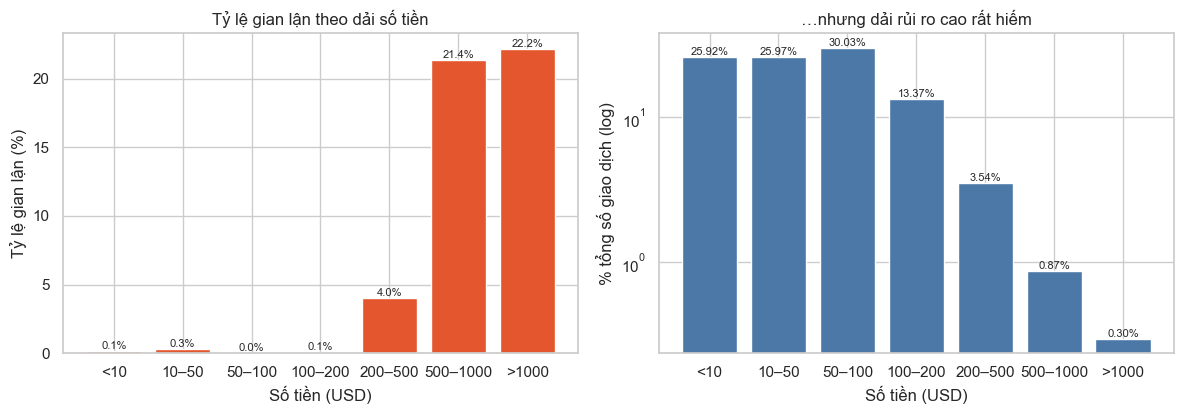

In [6]:
D.plot_amount_fraud_rate(sp, FIG / 'insight_amount.png');

Dưới 200 USD gần như không có fraud (≤0.3%); tính theo dòng, từ 500 USD trở lên ~21–22% là
fraud. **Đối chiếu theo đợt lộ thẻ:** tỷ lệ ≥500 USD trong nhóm fraud tụt từ 48,5% (mọi dòng) xuống
28,1% (chỉ dòng đầu đợt) — vẫn cao hơn RẤT nhiều so với 0,9% ở giao dịch hợp lệ, nên **tín hiệu vẫn
đúng hướng**, chỉ là mức độ bị phóng đại bởi đếm lặp trong cùng đợt, không nên trích nguyên số 21–22%
mà không nói rõ đây là thống kê theo dòng.

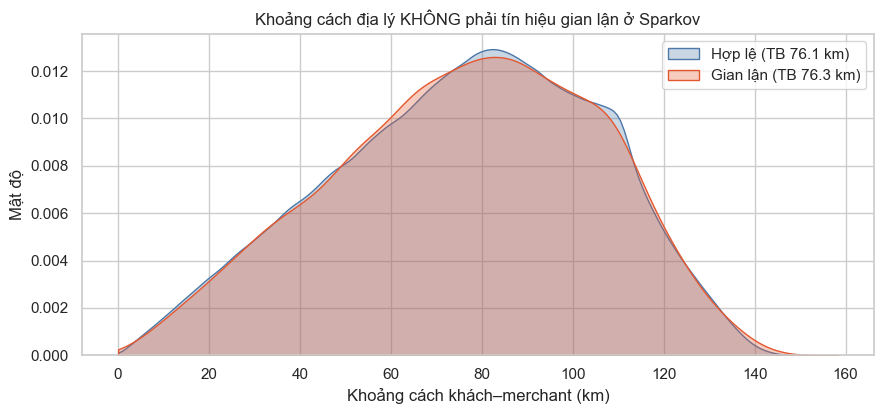

In [7]:
D.plot_distance_myth(sp, FIG / 'insight_distance.png');

**Giả thuyết sai**: "giao dịch xa nơi ở khách thì đáng ngờ". Khoảng cách khách–merchant của fraud và hợp lệ gần như trùng khít (76.3 km so với 76.1 km).
Feature địa lý (`lat`/`long`/`merch_lat`/`merch_long`) vì vậy khó đóng góp khi để nguyên dạng.

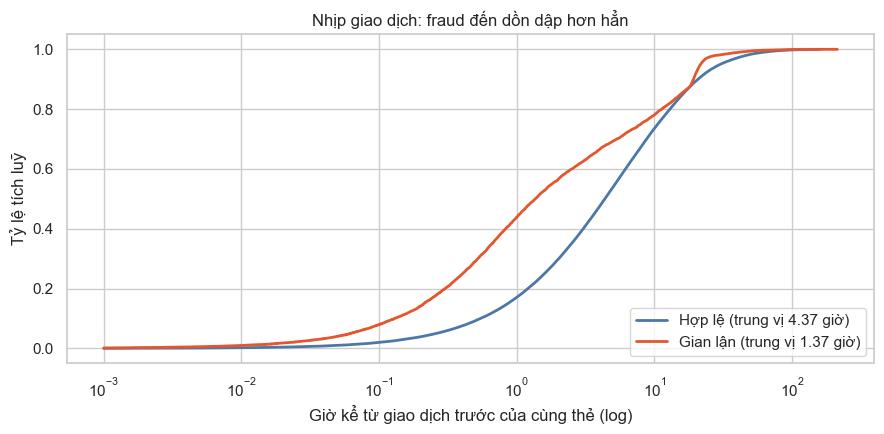

In [8]:
D.plot_velocity(sp, FIG / 'insight_velocity.png');

**Cần đọc lại — không đơn giản như "nhịp fraud nhanh hơn".** Tách theo `prev_is_fraud` thì
89,9% dòng fraud là *tiếp nối* 1 đợt lộ thẻ đang diễn ra (gap trung vị chỉ 1,08 giờ), còn dòng fraud
**đầu tiên** của mỗi đợt lại có gap trung vị **11,25 giờ — dài hơn cả** giao dịch hợp lệ (4,37 giờ).
Nghĩa là `gap_hours` sẽ giúp bắt được giao dịch fraud thứ 2 trở đi trong 1 đợt (lúc đó đợt lộ thẻ đã
bắt đầu), nhưng **không giúp gì cho việc bắt giao dịch fraud đầu tiên** — vốn là mục tiêu khó và có
giá trị nhất trong phát hiện gian lận thực tế. Không đủ căn cứ để đề xuất `gap_hours` như 1 feature
đơn giản; nếu dùng, nên tách rõ 2 vai trò trên. Không kiểm chứng chéo được trên ULB vì ULB không có
cột định danh thẻ.

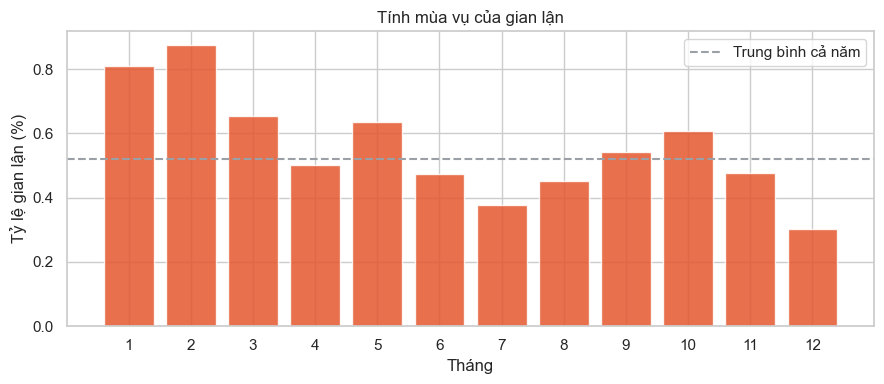

In [9]:
D.plot_month_seasonality(sp, FIG / 'insight_month.png');

Tỷ lệ fraud dao động theo tháng (cao nhất tháng 2 ~0.87%, thấp nhất tháng 12 ~0.30%). Vì train/test của Sparkov tách theo thời gian,
phân phối 2 tập có thể lệch nhau — cần nhớ khi đọc kết quả đánh giá.

## 2b. ULB — feature PCA ẩn danh

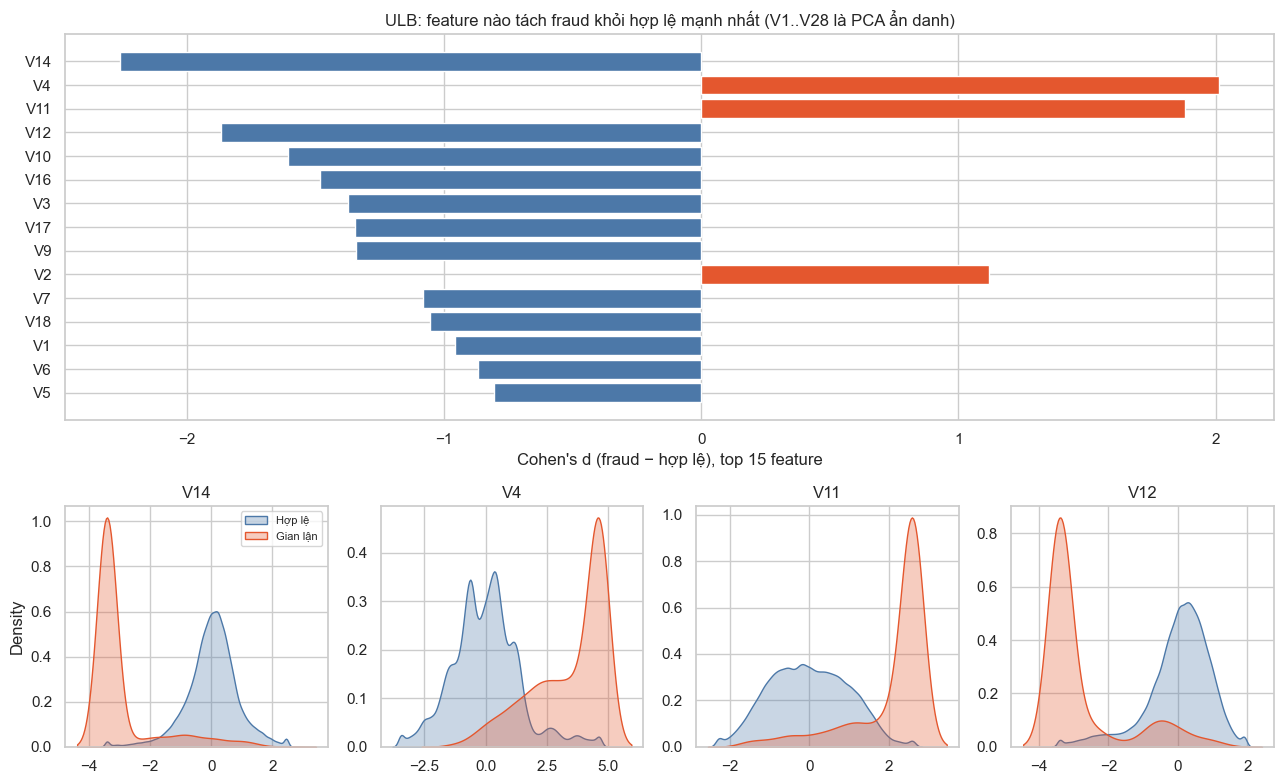

In [10]:
D.plot_ulb_top_features(ulb, ULB_TARGET_COL, save_path=FIG / 'insight_ulb_features.png');

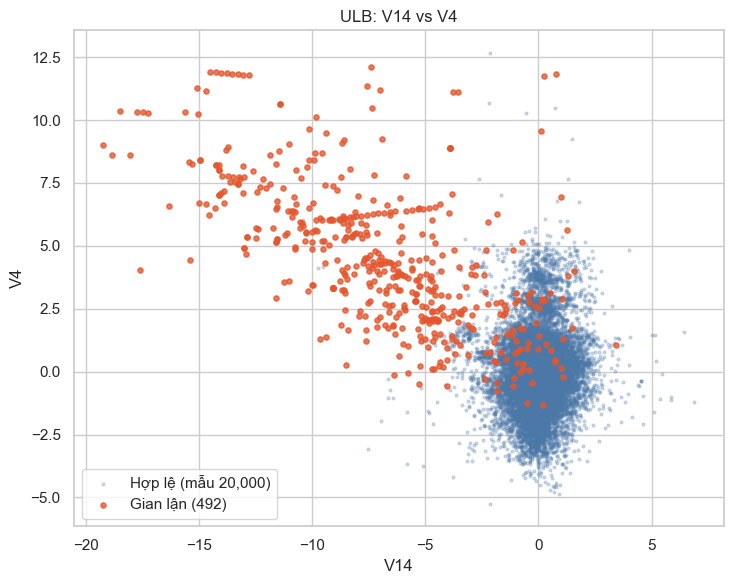

In [11]:
D.plot_ulb_scatter(ulb, ULB_TARGET_COL, save_path=FIG / 'insight_ulb_scatter.png');

V14, V4, V11, V12 tách fraud khỏi hợp lệ rất rõ (|Cohen's d| ≈ 1.9–2.3). Trong mặt phẳng V14–V4, fraud nằm gọn 1 vùng riêng —
khác Sparkov (tín hiệu rải trên nhiều feature gốc), ULB có vài feature "gánh" gần hết tín hiệu, nên thứ hạng SHAP dễ ổn định hơn.

## 3. SHAP — model nào nhìn feature nào
Train 3 model (Logistic Regression, Random Forest, XGBoost) trên 1 mẫu Sparkov đã encode với `class_weighting`, tính SHAP trên 1 eval set cố định
(100 fraud + 300 hợp lệ). ANN bỏ qua ở đây vì torch và xgboost trong cùng 1 kernel có thể xung đột OpenMP (xem `src/utils/isolation.py`); SHAP của ANN vẫn được tính trong CIES qua `DeepExplainer`. Hyperparameter lấy tự động từ `results/best_params.json`.

In [12]:
from src.imbalance.resamplers import apply_imbalance
from src.models.train import build_model, train_model
from src.explainability.shap_utils import compute_shap

tr = pd.read_parquet(PROCESSED_DATA_DIR / 'train_encoded.parquet')
te = pd.read_parquet(PROCESSED_DATA_DIR / 'test_encoded.parquet')
feats = [c for c in tr.columns if c != TARGET_COL]

sub = tr.sample(150_000, random_state=SEED)
Xtr, ytr = sub[feats].values, sub[TARGET_COL].values
ev = pd.concat([te[te[TARGET_COL] == 1].sample(100, random_state=SEED),
                te[te[TARGET_COL] == 0].sample(300, random_state=SEED)]).sample(frac=1, random_state=SEED)
Xev = ev[feats].values

shap_by_model, mabs_by_model = {}, {}
for m in ['logistic_regression', 'random_forest', 'xgboost']:
    X_res, y_res, cw = apply_imbalance('class_weighting', Xtr, ytr, seed=SEED)
    mod = train_model(build_model(m, input_dim=Xtr.shape[1], class_weights=cw, seed=SEED), X_res, y_res, model_name=m)
    shap_by_model[m] = compute_shap(mod, m, Xev, X_background=Xtr[:200])
    mabs_by_model[m] = np.abs(shap_by_model[m]).mean(axis=0)
    print(m, 'xong')

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


logistic_regression xong


random_forest xong


xgboost xong


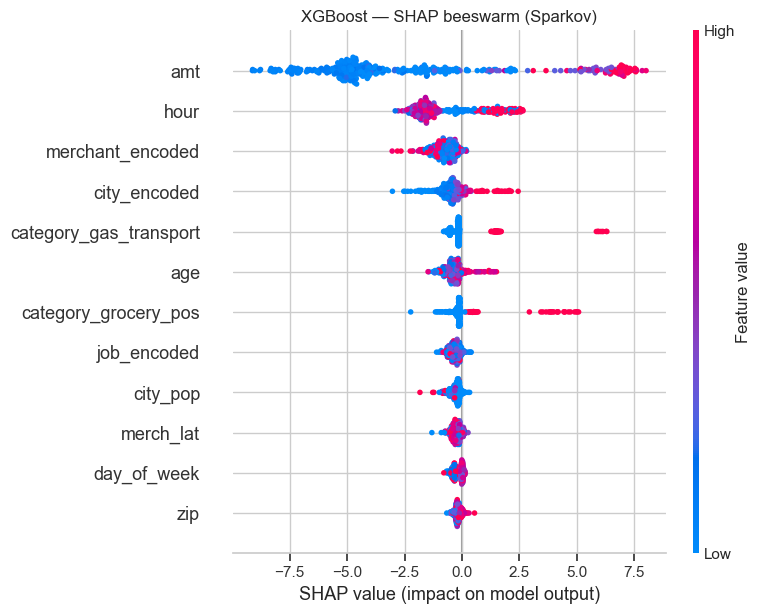

In [13]:
E.plot_shap_beeswarm(shap_by_model['xgboost'], Xev, feats, title='XGBoost — SHAP beeswarm (Sparkov)', save_path=FIG / 'shap_beeswarm_xgboost.png');

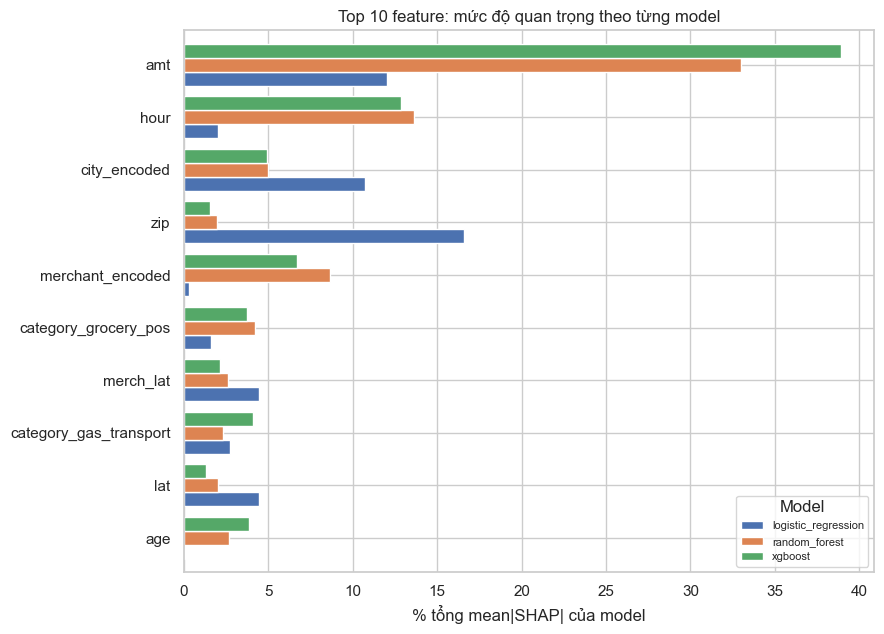

In [14]:
E.plot_shap_bar_by_model(mabs_by_model, feats, top_n=10, save_path=FIG / 'shap_bar_by_model.png');

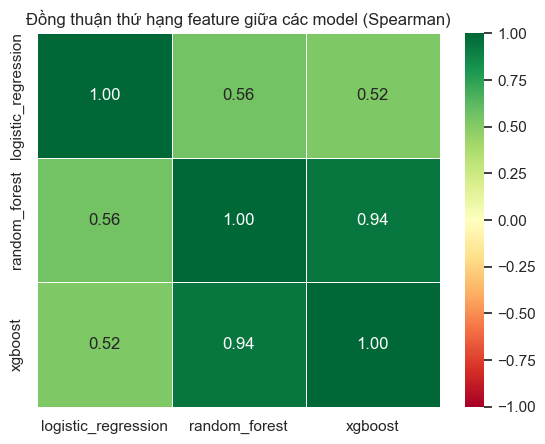

In [15]:
E.plot_model_rank_agreement(mabs_by_model, save_path=FIG / 'shap_model_agreement.png');

Feature quan trọng nhất (XGBoost): amt


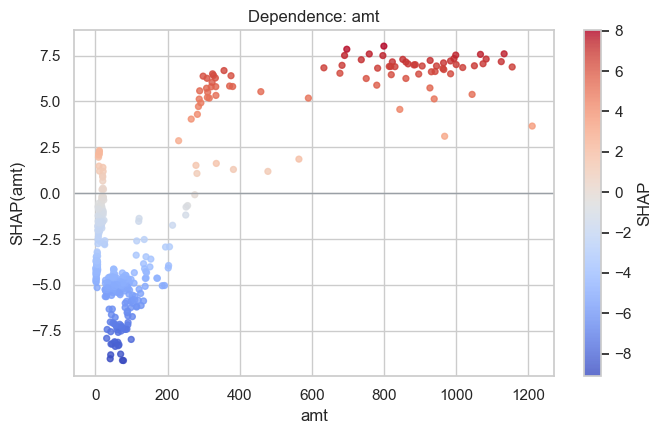

In [16]:
top_feat = feats[int(np.argmax(mabs_by_model['xgboost']))]
print('Feature quan trọng nhất (XGBoost):', top_feat)
E.plot_shap_dependence(shap_by_model['xgboost'], Xev, feats, top_feat, save_path=FIG / 'shap_dependence_top.png');

Đọc biểu đồ: **beeswarm** cho thấy chiều tác động (chấm đỏ = giá trị feature cao); **thanh so sánh** cho thấy các model dồn trọng số vào những feature nào;
**ma trận đồng thuận** đo mức các model xếp hạng feature giống nhau (Spearman) — nếu thấp, "feature quan trọng" phụ thuộc vào model bạn chọn.

Trong lần chạy thử: ở 2 model cây, `amt` áp đảo (~37–38% tổng SHAP) và `hour` đứng thứ hai; Random Forest và XGBoost gần như **đồng thuận hoàn toàn** (Spearman 0.95).
Logistic Regression thì **lệch hẳn** (0.55–0.58): nó coi `zip` (~17%) là feature quan trọng nhất, cao hơn cả `amt` (~12%) — 1 mã vùng mà 2 model cây gần như bỏ qua.
Nghĩa là câu trả lời cho "feature nào quan trọng" phụ thuộc vào họ model, không chỉ vào dữ liệu.

## 4. CIES — giải thích có ổn định không
Đọc kết quả từ notebook 04 (Sparkov) và 05 (ULB). Các biểu đồ theo từng run cần `mean_abs_shap` trong `run_logs`
(chỉ có ở kết quả chạy bằng code mới — kết quả cũ vẫn vẽ được heatmap tổng, không vẽ được phần theo run).

In [17]:
def load_results(name):
    p = RESULTS_DIR / name
    return json.load(open(p, encoding='utf-8')) if p.exists() else None

res_sp = load_results('cies_summary_results.json')
res_ulb = load_results('cies_summary_results_ulb.json')
df_sp = E.cies_results_to_df(res_sp) if res_sp else None
df_ulb = E.cies_results_to_df(res_ulb) if res_ulb else None
print('Sparkov:', 'có' if res_sp else 'CHƯA có (chạy notebook 04)', '| ULB:', 'có' if res_ulb else 'CHƯA có (chạy notebook 05)')

Sparkov: có | ULB: có


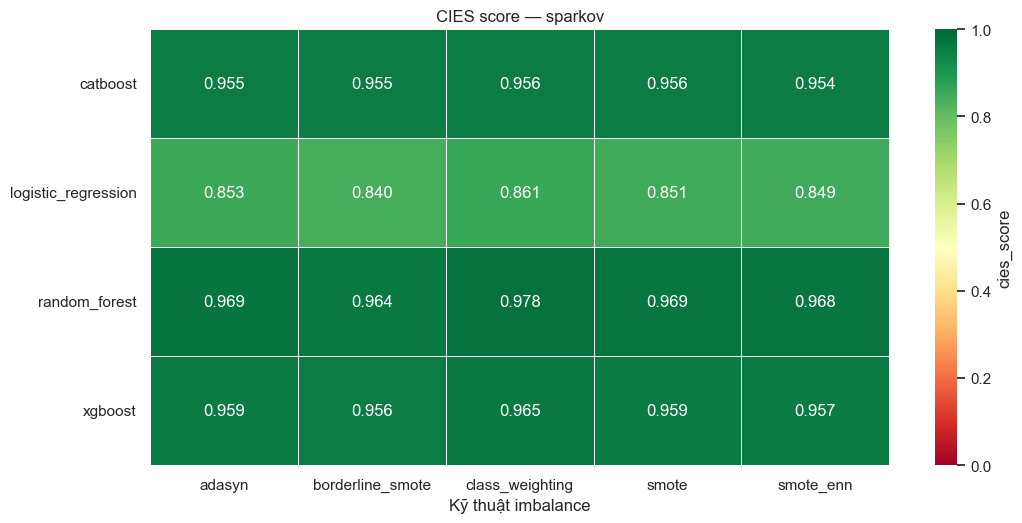

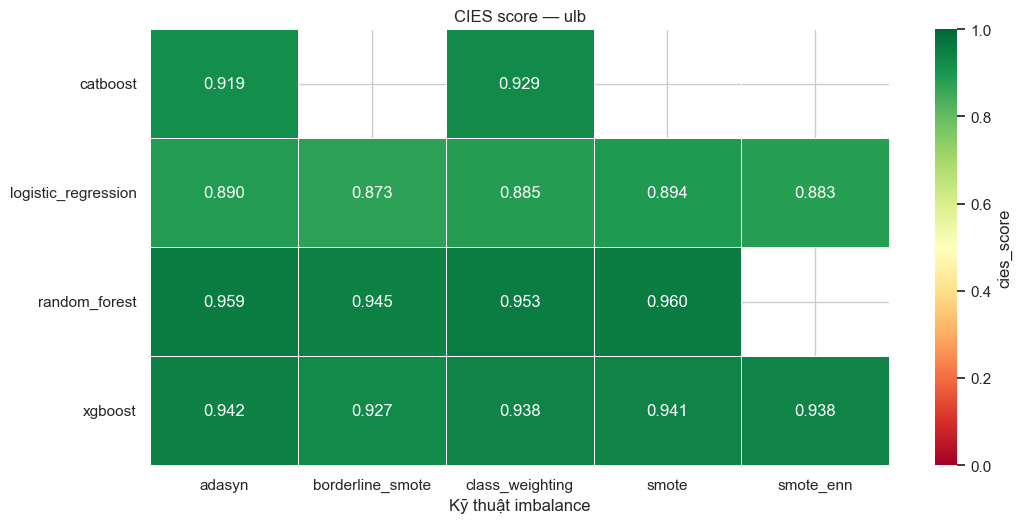

In [18]:
for name, df in [('sparkov', df_sp), ('ulb', df_ulb)]:
    if df is not None and len(df):
        E.plot_cies_heatmap(df, title=f'CIES score — {name}', save_path=FIG / f'cies_heatmap_{name}.png')
        plt.show()

=== sparkov — tổ hợp ổn định nhất: random_forest__class_weighting (CIES 0.978) ===


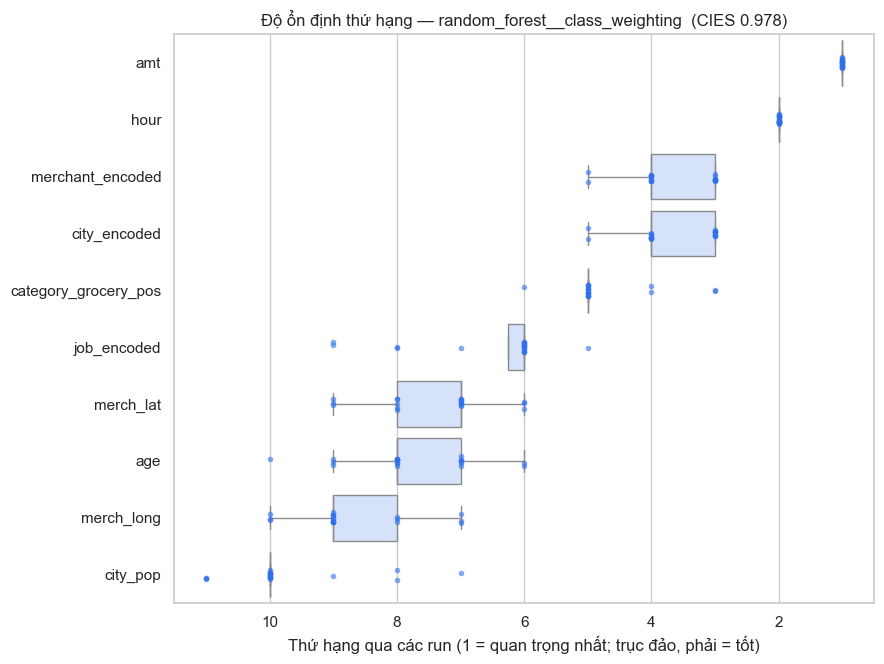

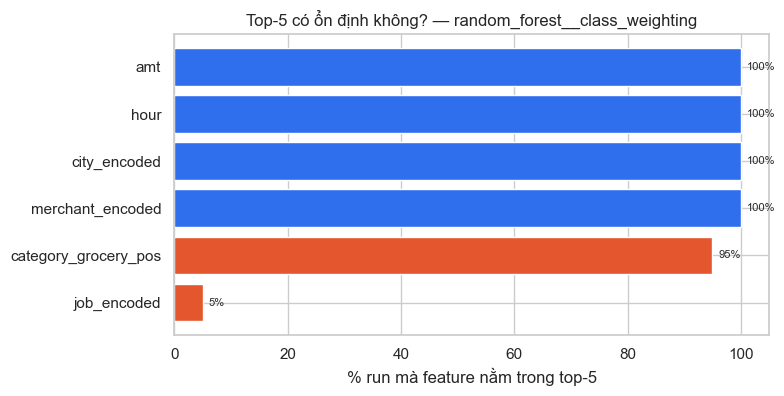

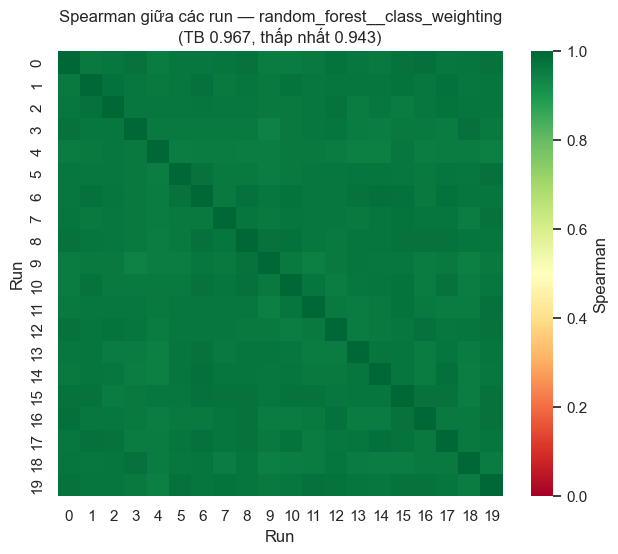

=== sparkov — tổ hợp kém ổn định nhất: logistic_regression__borderline_smote (CIES 0.840) ===


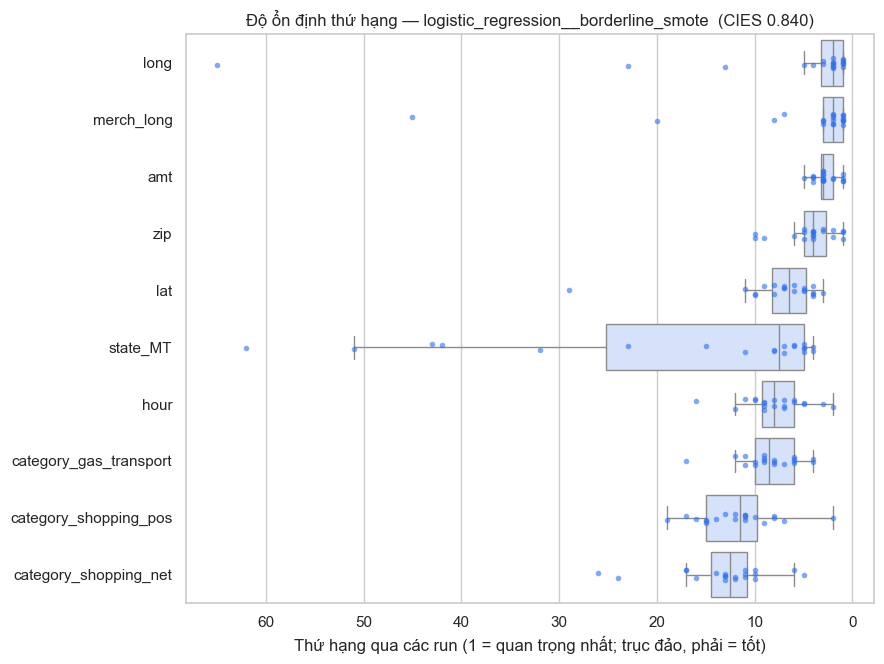

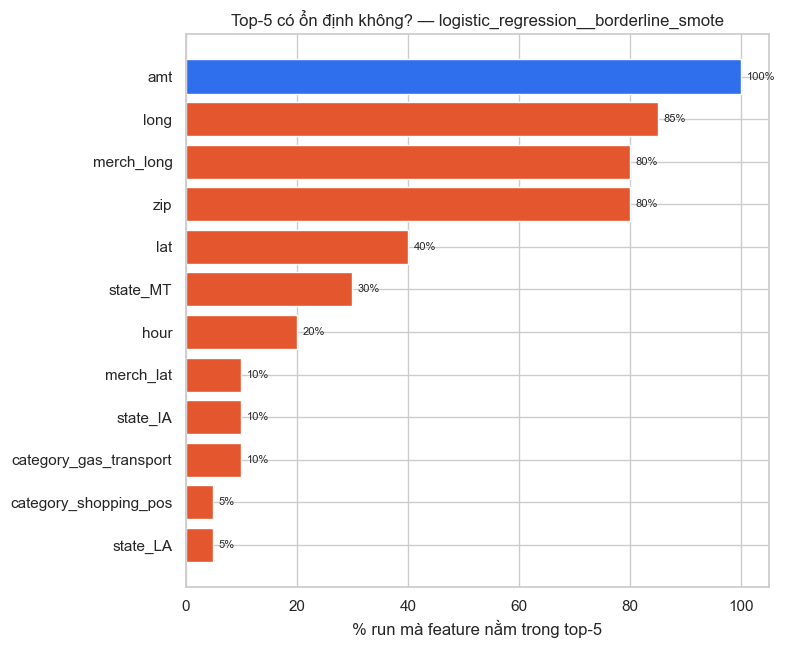

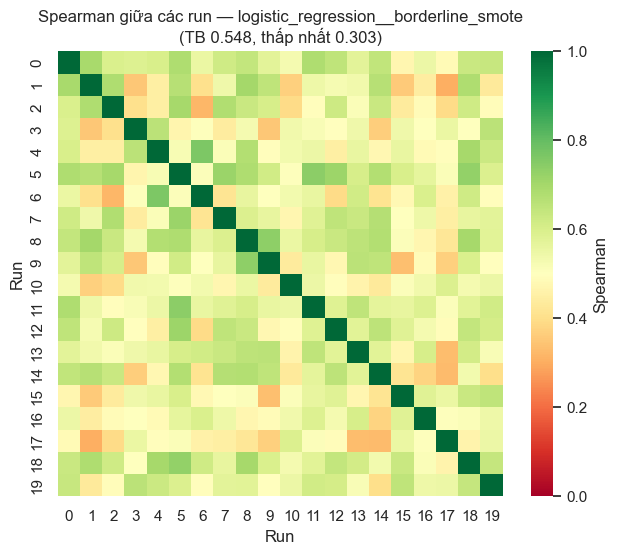

=== ulb — tổ hợp ổn định nhất: random_forest__smote (CIES 0.960) ===


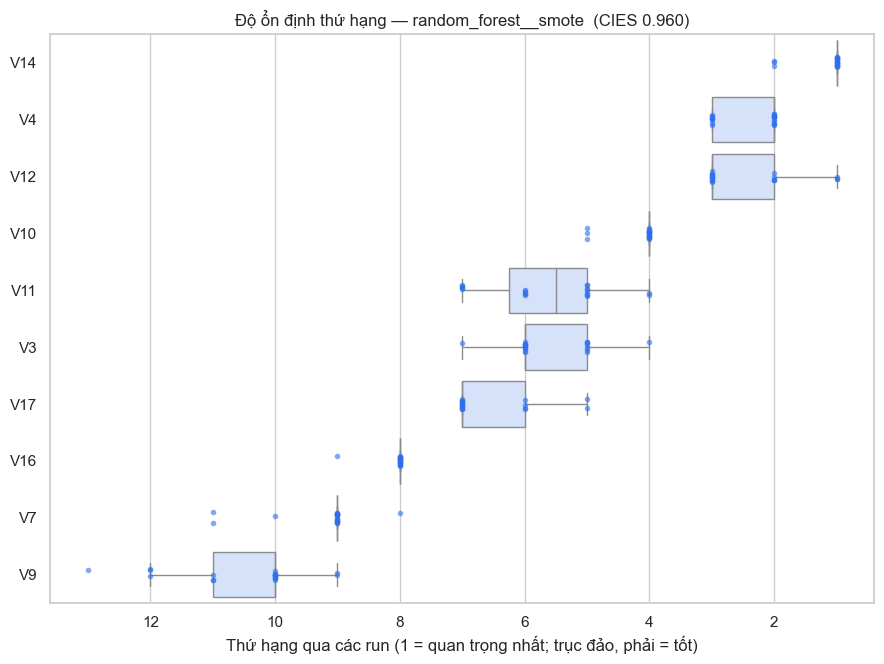

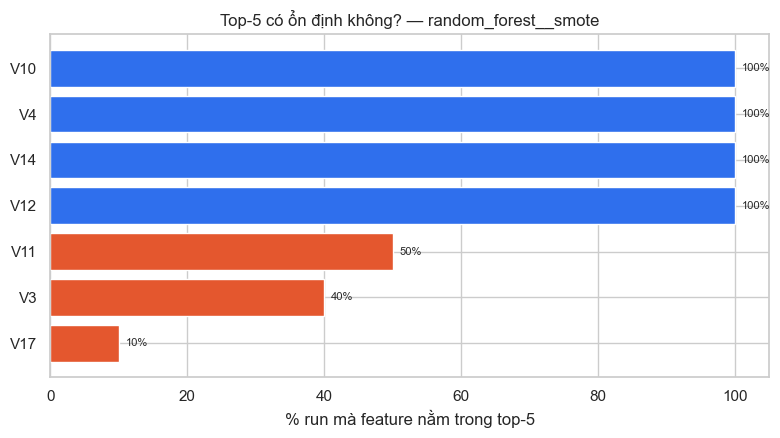

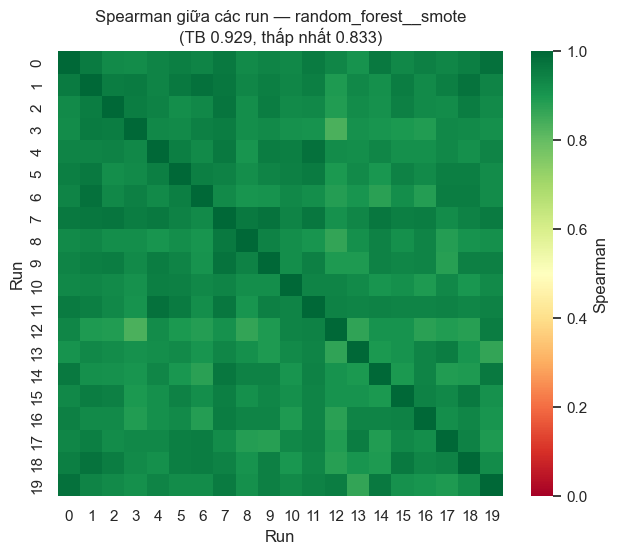

=== ulb — tổ hợp kém ổn định nhất: logistic_regression__borderline_smote (CIES 0.873) ===


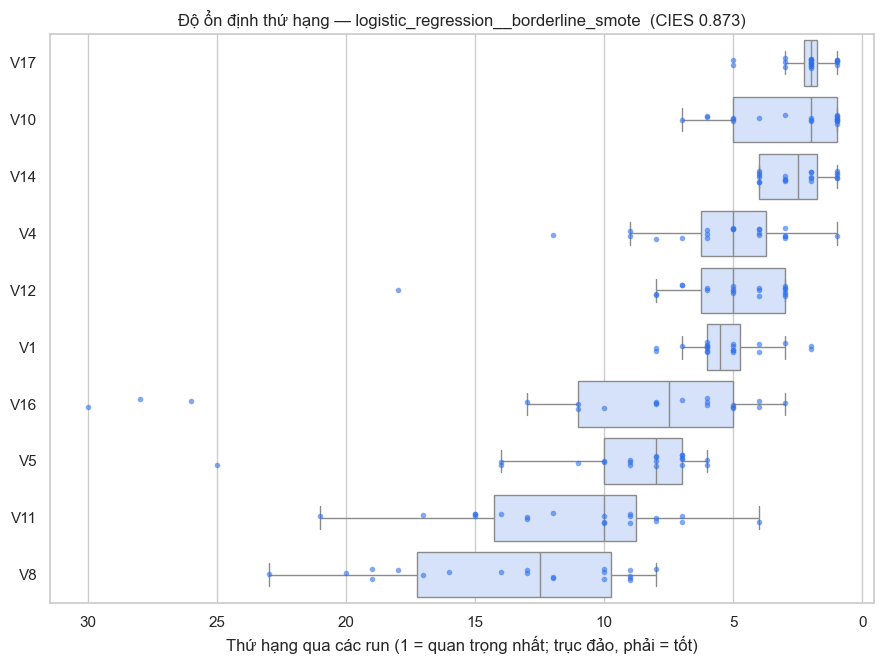

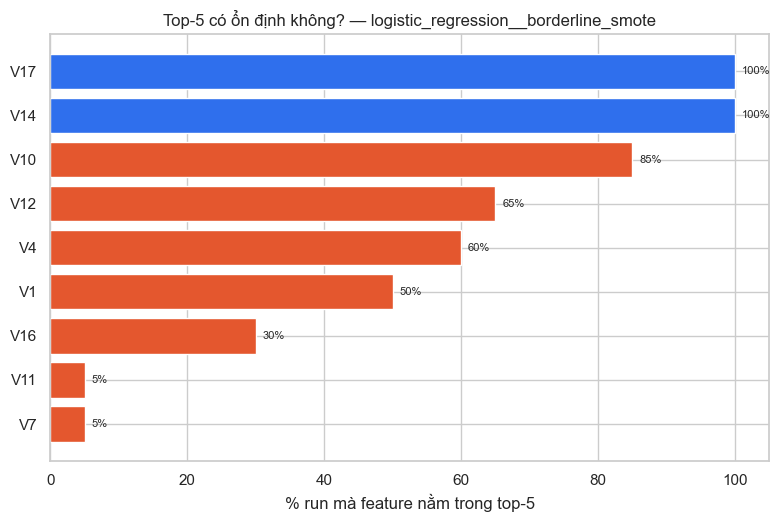

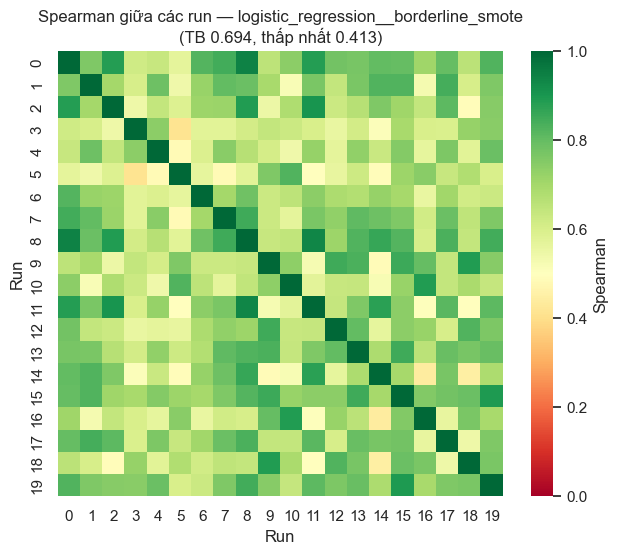

In [19]:
def pick(results, best=True):
    ok = [r for r in results if 'cies_metrics' in r and any('mean_abs_shap' in x for x in r.get('run_logs', []))]
    if not ok:
        return None
    return (max if best else min)(ok, key=lambda r: r['cies_metrics']['cies_score'])

for name, res in [('sparkov', res_sp), ('ulb', res_ulb)]:
    if not res:
        continue
    for tag, best in [('ổn định nhất', True), ('kém ổn định nhất', False)]:
        r = pick(res, best)
        if r is None:
            print(name, ': kết quả cũ, không có mean_abs_shap theo run — chạy lại CIES bằng code mới để vẽ phần này.')
            break
        print(f'=== {name} — tổ hợp {tag}: {r["combination"]} (CIES {r["cies_metrics"]["cies_score"]:.3f}) ===')
        key = 'best' if best else 'worst'
        E.plot_rank_stability(r, save_path=FIG / f'cies_rank_stability_{name}_{key}.png'); plt.show()
        E.plot_topk_frequency(r, save_path=FIG / f'cies_topk_{name}_{key}.png'); plt.show()
        E.plot_pairwise_spearman(r, save_path=FIG / f'cies_spearman_{name}_{key}.png'); plt.show()

Đọc biểu đồ: **hộp thứ hạng hẹp** = feature giữ nguyên vị trí qua mọi bootstrap; **top-k frequency < 100%** = ranh giới top-k không chắc chắn;
**ma trận Spearman có ô nhạt** = có cặp run cho giải thích khác hẳn nhau dù cùng model, cùng kỹ thuật, chỉ khác mẫu bootstrap.

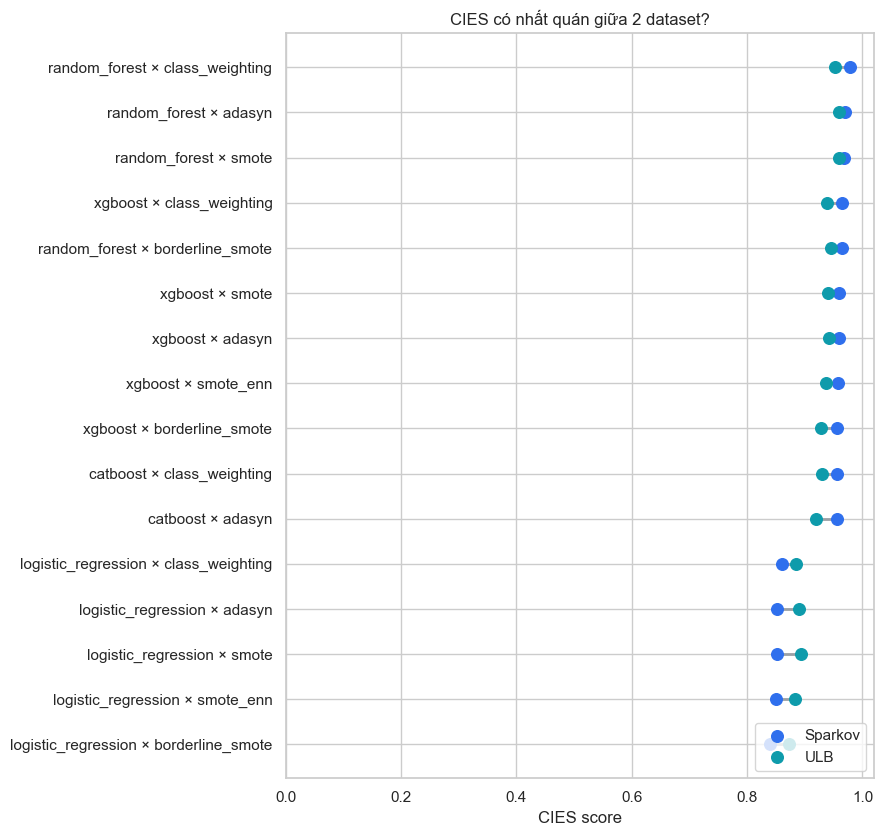

In [20]:
if df_sp is not None and df_ulb is not None and len(df_sp) and len(df_ulb):
    try:
        E.plot_cies_dataset_compare(df_sp, df_ulb, 'Sparkov', 'ULB', save_path=FIG / 'cies_sparkov_vs_ulb.png')
        plt.show()
    except ValueError as e:
        print(e)
else:
    print('Cần cả 2 file kết quả để so sánh Sparkov với ULB.')

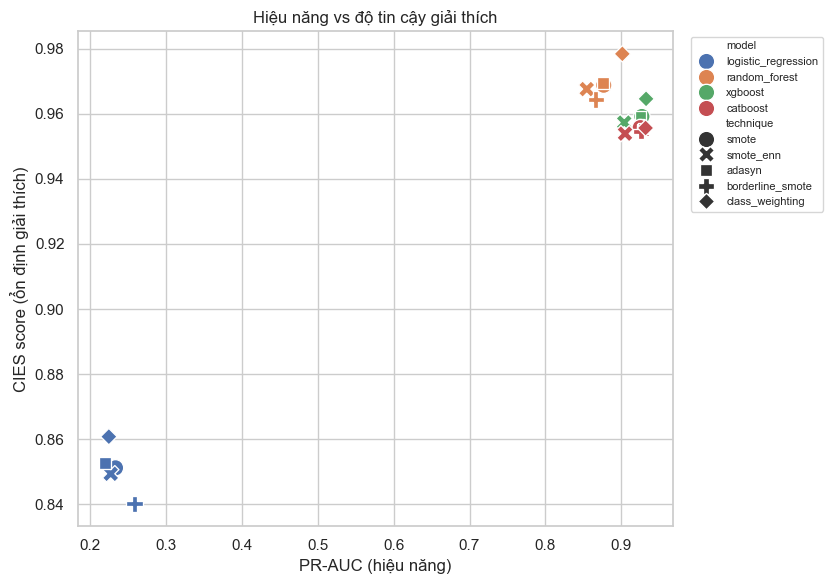

In [21]:
bench = RESULTS_DIR / 'model_benchmark_results.csv'
if df_sp is not None and len(df_sp) and bench.exists():
    E.plot_cies_vs_prauc(df_sp, pd.read_csv(bench), save_path=FIG / 'cies_vs_prauc.png')
    plt.show()
else:
    print('Cần cies_summary_results.json (notebook 04) và model_benchmark_results.csv (notebook 03).')

## 5. Kỹ thuật imbalance có đồng thuận với nhau về feature không?

CIES (mục 4) đo độ ổn định **giữa các lần bootstrap**, CÙNG 1 kỹ thuật — không nói lên việc
đổi kỹ thuật có đổi feature quan trọng hay không. Ở đây so **giữa 5 kỹ thuật** (đã cố định
model), dùng đúng rank-weighted distance của CIES (không phải Spearman — phạt nặng hơn khi
TOP feature bất đồng) trên vector mean|SHAP| đã trung bình qua 20 run của mỗi kỹ thuật.

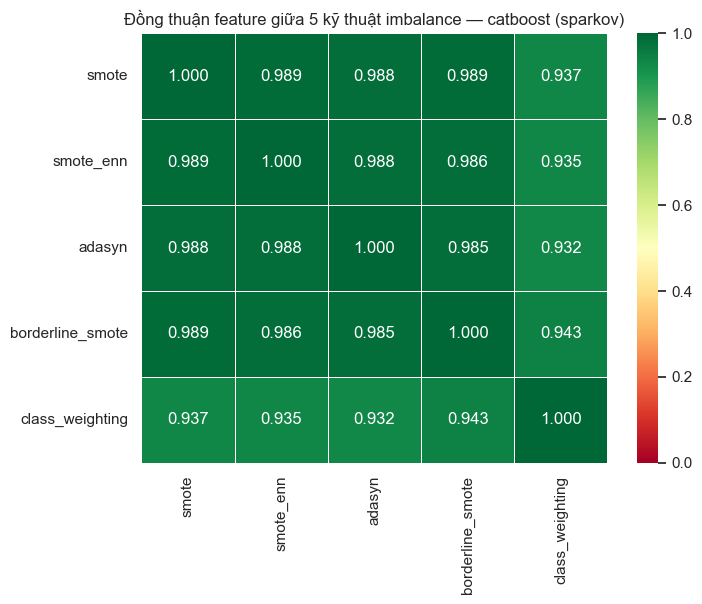

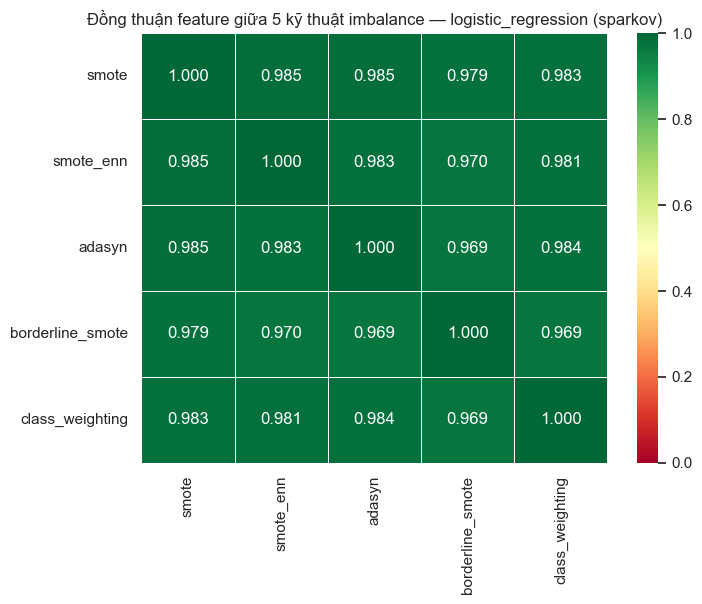

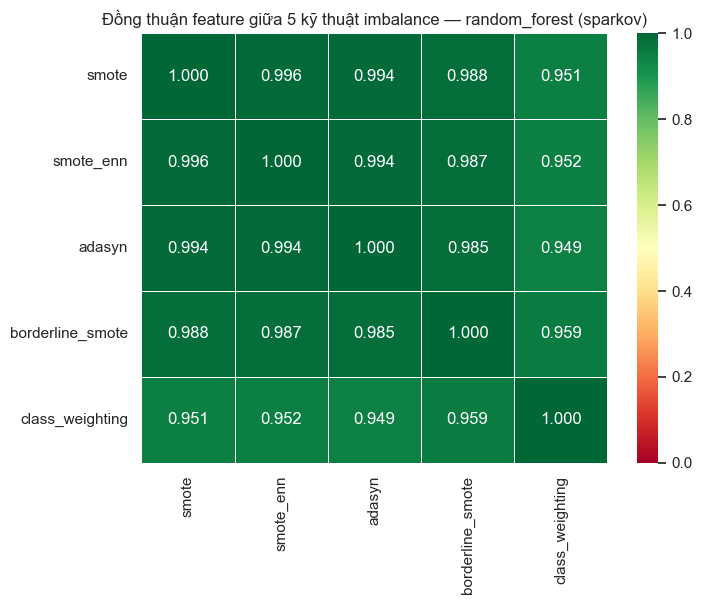

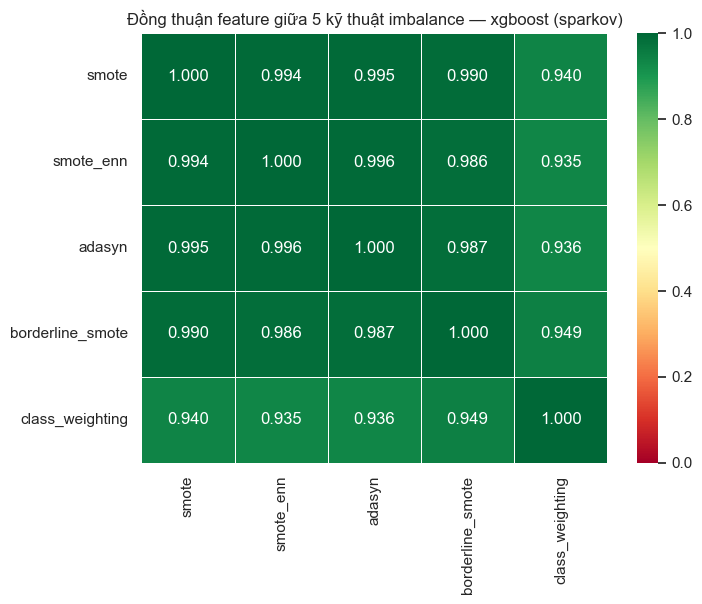

ulb/catboost: chưa đủ 5 kỹ thuật — bỏ qua


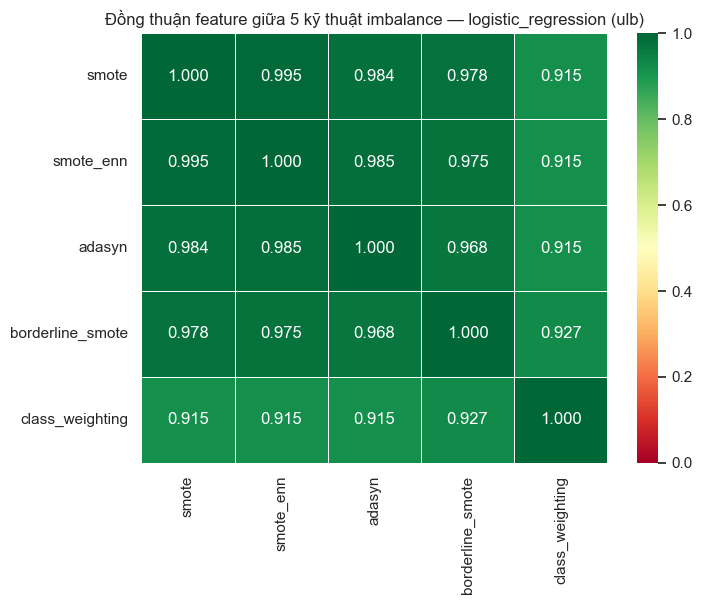

ulb/random_forest: chưa đủ 5 kỹ thuật — bỏ qua


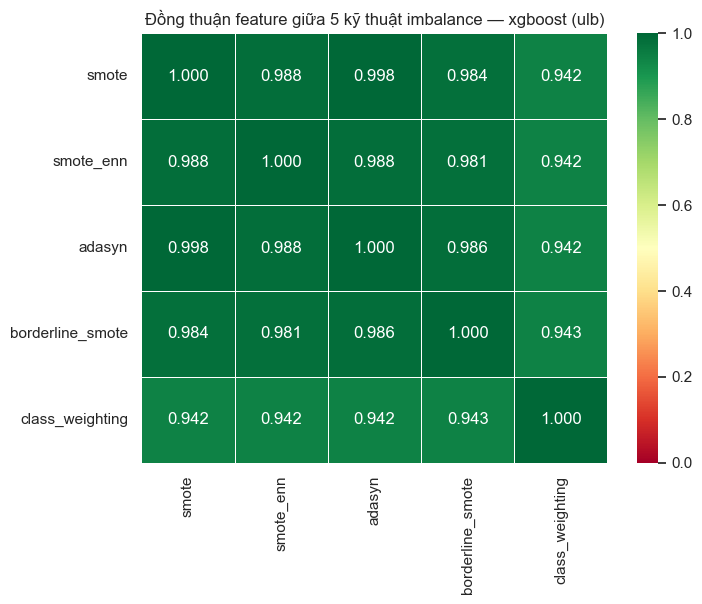

In [22]:
from src.config import IMBALANCE_TECHNIQUES

def mean_abs_by_technique(results, model_name):
    """Vector mean|SHAP| (trung bình qua N_RUNS) cho từng kỹ thuật của 1 model — None nếu thiếu kỹ thuật nào."""
    out = {}
    for r in results:
        if r.get('model_name') != model_name or 'cies_metrics' not in r:
            continue
        runs = [x['mean_abs_shap'] for x in r.get('run_logs', []) if 'mean_abs_shap' in x]
        if runs:
            out[r['imbalance_technique']] = np.mean(runs, axis=0)
    if set(IMBALANCE_TECHNIQUES) - set(out):
        return None
    return {t: out[t] for t in IMBALANCE_TECHNIQUES}  # thứ tự cố định

for name, results in [('sparkov', res_sp), ('ulb', res_ulb)]:
    if not results:
        continue
    model_names = sorted({r['model_name'] for r in results})
    for model_name in model_names:
        vecs = mean_abs_by_technique(results, model_name)
        if vecs is None:
            print(f'{name}/{model_name}: chưa đủ 5 kỹ thuật — bỏ qua')
            continue
        E.plot_condition_agreement(
            vecs,
            title=f'Đồng thuận feature giữa 5 kỹ thuật imbalance — {model_name} ({name})',
            save_path=FIG / f'technique_agreement_{name}_{model_name}.png',
        )
        plt.show()

Đọc ma trận: giá trị gần 1 = 2 kỹ thuật xếp hạng feature gần giống nhau (đặc biệt ở
top feature, vì dùng rank-weighted distance); gần 0 = 2 kỹ thuật "nhìn" model theo 2 cách khác
hẳn nhau. Nếu mọi ô đều gần 1 với mọi model, đó là bằng chứng trực tiếp rằng đổi kỹ thuật
imbalance không đổi feature nào được xem là quan trọng — dù CIES hay hiệu năng (PR-AUC/F1) có
thể vẫn khác nhau giữa các kỹ thuật.